# Applying Machine Learning



## Prerequisites

* Basics of Probability theory

* Module 7: Naive Bayes of *Machine Learning L1 course*

* Knowledge about text preprocessing



## Learning objective

* Describe text classification with its applications

* Recall conditional probability, Bayes theorem and Naive Bayes Classifier

* Describe Naive Bayes Classifier in context of text classification

* Implement and evaluate the Naive Bayes Classifier on a real world dataset for text classification

## Text Classification

You have learned what classification is in the ML Level 1 course. It's assigning a discrete class label for a sample. In this chapter, you will learn about **text classification**, where you need to assign a discrete class label to a text sample. The sample may be a simple sentence or an entire document. For example, **Spam Detection** is one of the most popular applications of text classification. It is a binary classification problem of predicting if an email is spam or not. Consider the following two emails:

1. *You have won a free discount coupon for cheapdeals.com. Redeem your discount coupon and buy products at a cheaper cost.*

2. *This mail is to inform you that there will be a workshop on storytelling this Sunday, 14th June 2017. Please respond to the calendar invite.*

You can see that the first mail is likely to be a spam. It consists of the words such as *free, discount, cheaper* and so on that is generally associated with spams. The second mail does not contain such words and seems like a legit mail. **Text classification is all about analyzing the text and then assigning it an appropriate class label.**




Another important application of text classification is **sentiment analysis**. The simplest form of sentiment analysis is a binary classification problem of predicting a text document's sentiment as either positive or negative. For example, consider the following two text documents:

1. *The action was superb and realistic; the story arc for the main antagonist was truly heartbreaking. Loved it.*

2. *Pathetic CGI. It looked like the animated cartoons of the early 2000s. No story whatsoever.*

These two documents are the reviews of some movies. The first one is a positive review, and the second one is a negative review. A more advanced form of sentiment analysis can be a multiclass classification problem of predicting a particular emotion from a whole range of emotions for a text document.

So how do you perform text classification problems? Manually? If there are few documents, classifying them manually might be an option. But most often, there are hundreds of thousands of documents. Manually classifying them is not an option. A rule-based system might work as long as the documents contain the words that the rule states. But what if some new words appear? The rule-based system breaks. The most practical solution for text classification is **supervised learning**. You pass a set of documents along with their labels to a machine learning model for training. Then for a new document, the model can predict the class that it belongs to.

In this chapter, you will learn about a supervised learning technique called **Naive Bayes** for text classification. All the text preprocessing steps you learned in the previous unit serve the final purpose of  **fitting a machine learning model**. This chapter will go through the complete pipeline of applying a machine learning model on text-based data. The model you will be applying is the **Naive Bayes Classifier**. You might have already gone through it in the course *Machine Learning Level 1*. However, let's recall some topics that are important for this chapter.




## Revisit: Conditional Probability

The conditional probability of an event is the probability of that event occurring, given that another event has occurred. Suppose there are two events $A$ and $B$. Then the probability of occurrence of event $A$ given the event $B$ has already occurred is denoted as $P(A|B)$ and defined as:

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$
where $P (A\cap B) $ is the probability of both the events $A$ and $B$ occurring.
  




**Example**

Let's consider an example. Its monsoon season this time of the year and the probability of raining today is 0.8. Its a weekday, you are working from home, so the probability of you going out today is very low, say 0.4. Suppose the probability of both the events happening *i.e.,* raining and you going out is 0.2. What is the probability of you going out given it is raining?

Here,

$P(\text{rain}) = 0.8$

$P(\text{out}) = 0.4$

$P(\text{rain} \cap \text{out}) = 0.2$

$P(\text{out}|  \text{rain}) = \frac{P(\text{rain} \cap \text{out})}{P(\text{rain})} = \frac{0.2}{0.8} = 0.25$

Thus, the probability of you going out given it is raining is 25\%. That means you are less likely to go out if it's raining already.

## Revisit: Bayes Theorem

Bayes theorem is an extremely powerful theorem in the field of statistics. It is used to find the probability of a hypothesis given its evidence.

According to the Bayes Theorem,<br>
$$P(H|E) = \frac{P(E|H)\ P(H)}{P(E)}$$<br>
where,
* H is the **Hypothesis**,
* E is the **Evidence/Data** that supports our hypothesis,
* $P(H|E)$ is the **posterior probability** of Hypothesis given Evidence,
* $P(H)$ is the **prior** probability of the hypothesis,
* $P(E)$ is the probability of evidence,
* $P(E|H)$ is the conditional probability (likelihood) of Evidence given Hypothesis.






**Example**  
Suppose you are feeling unwell. You search the web and find out that your symptoms match a rare disease called Dragon Skin. This disease causes the skin of the patient to be scaled like dragons! You hypothesize that you are suffering from the disease. Here the **hypothesis $(H)$ is that you are suffering from dragon skin and the symptoms are the evidence $(E)$ that supports your hypothesis.**



You search the web about the dragon skin and come up with the following facts:

1. 95 % people show symptoms as yours provided they have dragon skin *ie.* $P(E| H) = 0.95$
2. Only 1 among hundred thousand people suffer from dragon skin *ie.* $P(H) = 0.00001$
3. The symptoms you have are pretty common like fever and nausea which happens to 1 in every 100 people ie. $P(E) = 0.01$


After knowing all the facts, you use Bayes Theorem to calculate the probability that you are suffering from dragon skin given the symptoms.

$P(H|E) = \frac{P(E|H)P(H)}{P(E)}= \frac{0.95 * 0.00001}{0.01} = 0.00095 = 0.95\%$

Hence, there is a very low probability that you are suffering from dragon skin. So you breathe a sigh of relief!

## Naive Bayes for Text Classification

In a classification problem, Bayes' theorem can compute the probability that a particular sample falls in a particular class $y$ given it's set of features $x_1, x_2 ... x_i ... x_n$. Relating to the terms in Bayes Theorem, the **hypothesis is that the sample belongs to a particular class and the evidence is the sample's features.** Similarly,

$P(H) = P(y)$

$P(E) = P(x_1, x_2 ... x_i ... x_n)$

$P(E|H) = P(x_1, x_2 ... x_i ... x_n|y)$

$P(H|E) = P(y|x_1, x_2 ... x_i ... x_n)$

Using Bayes Theorem, for each class $y \in \{0,1,2....... k\}$, we calculate $P(H|E)$ *ie.*

$$P(y|x_1, x_2 ... x_i ... x_n) = \frac{P(x_1, x_2 ... x_i ... x_n|y) \ P(y)}{P(x_1, x_2 ... x_i ... x_n)} \ ........(1)$$

\

In the context of text classification, a sample is a text document, and the features $x_1, x_2,.. x_i, ...x_n$ are the words present in the document. You need to find the class that the document belongs to. So we can write the above expression in a simpler form as:

$$P(\text{class}|\text{document})=\frac{P(\text{document}|\text{class}) \ P(\text{class})}{P(\text{document})}$$

where,

* $P(\text{class}|\text{document}) = P(y|x_1, x_2 ... x_i ... x_n)$ is the probability of getting a particular class given the words present in the document.

* $P(\text{document}|\text{class}) = P(x_1, x_2 ... x_i ... x_n|y)$ is the probability of getting the words present in a document given a particular class.

* $P(\text{class}) = P(y)$ is the probability of getting a particular class.

* $P(\text{document}) = P(x_1, x_2 ... x_i ... x_n)$ is the probability of getting the words present in a document.







### The Naive Assumption

You might be thinking, why is the Naive Bayes classifier called 'naive'? Well, it is because of the assumption it makes. It assumes that each feature is independent of the other features. This is a naive assumption that is rarely true in reality.

In the context of text classification, the assumption is that the occurrence of a feature, like one word, is not dependent on the occurrence of another. Consider a spam classification. The naive assumption states that the fact that a message contains the word "cheap" does not influence the probability of it having the word "discount." In the real world, a spam message containing the word "discount" has a higher chance of having the word "cheap" too.

When the events are independent of each other, their joint probabilities can be calculated as the product of the probabilities of individual events. As a consequence of this naive assumption, $P(\text{document}|\text{class})$ can be written as:

$$P(x_1, x_2 ... x_i ... x_n|y) = \prod_i^n P(x_i|y) \ .........(2)$$




### Prediction

We then predict the $\text{class}$ that has the highest value of $P(\text{class}|\text{document})$ *ie.*

$$\hat{y} = \operatorname{arg}\underset{y}{\operatorname{max}}\ P(y|x_1, x_2 ... x_i ... x_n)$$

\

From $(1)$ and $(2)$ we can write,

$$\hat{y}=\operatorname{arg}\underset{y}{\operatorname{max}}\  \frac{\prod_i^n P(x_i|y) \ P(y)}{P(x_1, x_2 ... x_i ... x_n)}$$

\

When comparing across multiple classes, the denominator $P(x_1, x_2 ... x_i ... x_n)$ is a constant term. So Naive Bayes can be written in a more succinct form as:

$$\hat{y} = \operatorname{arg}\underset{y}{\operatorname{max}}\  \prod_i^n P(x_i|y) \ P(y)$$


Hence, Naive Bayes predicts a document to belong to the class that maximizes the product of probability of getting the document's words given that class and the prior probability of that class.

### Training the Naive Bayes Classifier

Now that you have the expression for Naive Bayes let's calculate each term in it. You can use the number of times the words and the classes appear in the dataset. If you recall, the **Bag of Words** model is an appropriate vectorization method for this task. If you recall, whenever the features represent the frequency or count of some event, we use the **Multinomial Naive Bayes**. So let's understand how Multinomial Naive Bayes classifies a text document.

Let's start with $P(y)$. It is pretty easy to calculate. It is the fraction of the documents that belong to class $y$. *i.e.*

$$P(y) = \frac{\text{No. of documents that belong to } y}{\text{Total no. of documents}}$$

Let $N_y$ be the number of documents that belong to class $y$ and $N$ be the total number of documents in the dataset. Then

$$P(y)= \frac{N_y}{N}$$

Now comes the other term $\prod_i^n P(x_i|y)$. To calculate this product term,  you need to calculate $P(x_i|y)$ for each of the $n$ words. For a particular word $x_i$,

$$P(x_i|y) = \frac{\text{No. of times }x_i \text{ appears in class } y}{\text{Total number of words in class } y}$$

But how do you calculate this? The first thing you need to do is create a collection of all the documents that belong to class $y$. Then count the number of times the word $x_i$ appears in that collection and the total number of words in that collection. Using those, you can easily calculate $P(x_i|y)$.

But there’s a problem with this approach. Consider a particular word $x_i$ that never appears in a particular class $y$ in the training set. Then the number of times that $x_i$ appears in class $y$ is equal to $0$. As a result $P(x_i|y) = 0$. This $P(x_i|y)$ for that particular word is multiplied with the probabilities corresponding to other words. As a result, the whole product term $\prod_i^n P(x_i|y)$ becomes $0$. This in turn causes the posterior probability of class $y$ to become $0$:
\begin{align}
P(y|x_1, x_2 ... x_i ... x_n) &= \prod_i^n P(x_i|y) \ P(y)\\
&= 0 \times P(y) \\
&= 0
\end{align}

Moreover, if a word never appears in training set irrespective of the class, the posterior probabilities of all the classes will be equal to $0$. To avoid this, you can use the following formula to calculate $P(x_i|y)$:

$$P(x_i|y) = \frac{\text{No. of times }x_i \text{ appears in class } y\ +\ 1}{\text{Total number of words in class } y\ +\ |V|}$$

Where $|V| =$ Size of the vocabulary *i.e.,*  number of unique words in the dataset.

This is also known as *add-one smoothing*.




### Example: Simple Sentiment Analysis

Consider the following six movie reviews. Five of them are in training set along with their corresponding labels, positive or negative. One of them is in the test set.

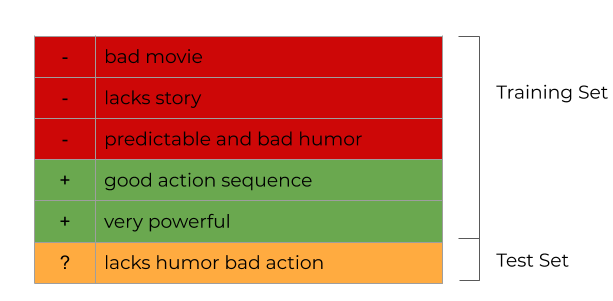

There are $12$ unique words in the training set. So $|V| = 12$
There are 3 negative reviews and 2 positive reviews among the 5 reviews present in the training set. So $P(-) = \frac{3}{5} = 0.6$ and $P(+) = \frac{2}{5} = 0.4$. Now let's calculate the probability of each word present in the test document given each of the classes.

\

Probability of the words given the **negative** class:

$P(\text{lacks}|-) = \frac{1+1}{8+12} = \frac{2}{20} = 0.1$

$P(\text{humor}|-) = \frac{1+1}{8+12} = \frac{2}{20} = 0.1$

$P(\text{bad}|-) = \frac{2+1}{8+12} = \frac{3}{20} = 0.15$

$P(\text{action}|-) = \frac{0+1}{8+12} = \frac{1}{20} = 0.05$

\

Probability of the words given the **positive** class:

$P(\text{lacks}|+) = \frac{0+1}{5+12} = \frac{1}{17} = 0.0588$

$P(\text{humor}|+) = \frac{0+1}{5+12} = \frac{1}{17} = 0.0588$

$P(\text{bad}|+) = \frac{0+1}{5+12} = \frac{1}{17} = 0.0588$

$P(\text{action}|+) = \frac{1+1}{5+12} = \frac{2}{17} = 0.1176$

\

Now let's calculate the posterior probability for each of the classes.

\begin{align}
P(-|\text{'lacks', 'humor', 'bad', 'action'}) &= P(\text{lacks}|-) \times P(\text{humor}|-) \times P(\text{bad}|-) \times P(\text{action}|-) \times P(-)
\\
&= 0.1 \times 0.1\times 0.15\times 0.05 \times 0.6\\
&= 4.5\times10^{-5}
\end{align}

\begin{align}
P(+|\text{'lacks', 'humor', 'bad', 'action'}) &= P(\text{lacks}|+) \times P(\text{humor}|+) \times P(\text{bad}|+) \times P(\text{action}|+) \times P(+)
\\
&= 0.0588 \times 0.0588\times 0.0588\times 0.1176 \times 0.4\\
&= 9.5\times10^{-6}
\end{align}

\

Since $P(-|\text{'lacks', 'humor', 'bad', 'action'}) > P(+|\text{'lacks', 'humor', 'bad', 'action'})$, the review is negative.


# SMS Spam Detection

Now that you know the basic theory behind text classification using Naive Bayes, let's implement it on a real-world dataset. In this section, you will be implementing the entire pipeline for text classification, starting from importing the dataset to applying a machine learning model and evaluating it. You will implement a text classification model for **SMS Spam Detection** *i.e.,* a model that classifies whether a given SMS is spam or not. You will use the same [SMS Spam Collection](https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection) dataset that you had used in the previous unit.


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the dataset

In [ ]:
dataset = pd.read_csv('https://storage.googleapis.com/codehub-data/1-lv1-7-1-spam.tsv', sep='\t', names=['spam', 'sms'])
dataset.head()

## Encoding the target variable 'spam'

You can see that the target variable 'spam' has text values. Before preprocessing the messages, let’s quickly encode the target variable to numerical values. You can use [`sklearn.preprocessing.LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) for that purpose. Let's encode 'spam' as 1 and 'ham' as 0.



In [ ]:
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
dataset['spam'] = enc.fit_transform(dataset['spam'])
y = dataset['spam']
dataset.head()

,spam,sms
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## Text Preprocessing

Before you fit a model, you need to preprocess the messages contained in the 'sms' column of the dataset. You have learned about all the necessary steps to preprocess a dataset in the previous unit. So let's quickly preprocess the texts using the codes from previous unit.

In [ ]:
# Text Cleaning

def clean_text(string):

    import re
    from bs4 import BeautifulSoup

    # Removing URLs
    string = re.sub("http\S+", " ", string)

    # Removing html tags
    string = BeautifulSoup(string, 'lxml')
    string = string.get_text()

    # Decontraction
    string = re.sub(r"n\'t", " not", string)
    string = re.sub(r"\'re", " are", string)
    string = re.sub(r"\'s", " is", string)
    string = re.sub(r"\'d", " would", string)
    string = re.sub(r"\'ll", " will", string)
    string = re.sub(r"\'t", " not", string)
    string = re.sub(r"\'ve", " have", string)
    string = re.sub(r"\'m", " am", string)

    # Removing Punctuations and numbers
    string = re.sub('[^A-Za-z]+', ' ', string)

    return string


# Text Normalization

def normalize_text(tokens):

    from nltk.stem import PorterStemmer

    # lowercasing all the tokens
    tokens = [token.lower() for token in tokens]

    # stemming all the tokens
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(token) for token in tokens]

    return tokens

In [ ]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
from nltk.corpus import stopwords
eng_stopwords = stopwords.words('english')

corpus = [] # list containing all the preprocessed messages in dataset

# for each message in the document.
for message in dataset['sms']:

  # cleaning the message
  message = clean_text(message)

  # tokenizing the message
  tokens = word_tokenize(message)

  # text normalization
  tokens = normalize_text(tokens)

  # stopwords removal
  tokens = [token for token in tokens if token not in eng_stopwords]

  # getting back the original text
  string = " ".join(tokens)

  corpus.append(string)

# Printing top 5 documents of corpus
for document in corpus[:6]:
  print(document)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
go jurong point crazi avail onli bugi n great world la e buffet cine got amor wat
ok lar joke wif u oni
free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli
u dun say earli hor u c alreadi say
nah think goe usf live around though
freemsg hey darl week word back would like fun still tb ok xxx std chg send rcv


In [ ]:
# Text Vectorization

from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(max_features=500)
X = vectorizer.fit_transform(corpus).toarray()
pd.DataFrame(X, columns=vectorizer.get_feature_names())

,abl,abt,account,actual,address,afternoon,age,ah,aight,alreadi,alright,also,alway,ani,anoth,answer,anyon,anyth,anyway,appli,ard,around,ask,attempt,await,award,away,awesom,babe,babi,back,bad,bath,beauti,becaus,bed,befor,believ,best,better,...,want,wat,watch,way,week,weekend,weekli,well,wen,went,whi,wid,wif,wife,win,wish,without,wk,wo,wonder,wont,word,work,world,worri,wot,would,www,xma,xx,xxx,ya,ye,yeah,year,yesterday,yet,yo,yr,yup
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5567,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5568,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5569,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5570,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


## Splitting into train set and test set






In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 0, stratify=y)

## Fitting the Multinomial Naive Bayes classifier

 Due to the previous steps of text preprocessing, fitting a classifier will be very easy. You will fit the multinomial Naive Bayes classifier using the [`MultinomialNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB) class from the sklearn library. Instantiating the class takes three arguments:

* `alpha` (float): Parameter that controls the additive smoothing. Previously you learned about add-one smoothing with alpha = 1. By default, `alpha = 1`.

* `fit_prior` (bool): If true prior probabilities are learned from the data else uniform prior is used. By default, `fit_prior = True`.

* `class_prior` (array): Instead of learning the prior probability or using uniform priors, you can provide specific prior probabilities of each class in this array. By default, `class_prior = None`.

Let's use the default values of these parameters to instantiate the class and create an object called `multinomial_nb`.


In [ ]:
from sklearn.naive_bayes import MultinomialNB

multinomial_nb = MultinomialNB()
multinomial_nb.fit(X_train, y_train)

MultinomialNB(alpha=1.0, class_prior=None, fit_prior=True)

## Making Predictions

Now that you have trained the model, let's make some predictions on the test set. We can use the [`predict_proba`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB.predict_proba) method of `MultinomialNB` object to predict the posterior probability *ie.* $P(y|x_1,x2,...,x_n)$ for each class $y\in\{0,1\}$ for the test set.

In [ ]:
y_pred = multinomial_nb.predict_proba(X_test)
pd.DataFrame(y_pred, columns=['P(y=0|X)','P(y=1|X)']).head(5)

,P(y=0|X),P(y=1|X)
0,0.983485,0.016515
1,0.999866,0.000134
2,0.990857,0.009143
3,0.997711,0.002289
4,0.017250,0.982750


You can use the [`predict`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html#sklearn.naive_bayes.MultinomialNB.predict) method of `multinomial_nb` to directly predict the class for the test set.

In [ ]:
y_pred = multinomial_nb.predict(X_test)
pd.DataFrame(y_pred, columns=['Predicted']).head()

,Predicted
0,0
1,0
2,0
3,0
4,1


As you can see that the `multinomial_nb` is actually predicting the class with the highest posterior probability.

## Model Evaluation

After fitting our model, its time to evaluate the model's performance on unseen data. We will evaluate the model's performance on the testing set. Let's calculate accuracy, precision, recall, and f1 score of our model.






In [ ]:
from sklearn.metrics import accuracy_score

accuracy =  accuracy_score(y_test, y_pred)
print('Accuracy= ',accuracy)

Accuracy=  0.9650224215246637


Wow! the model has a pretty good accuracy of 0.965 meaning 96.5% of its predictions are correct. But as you know accuracy can be a misleading metric in case the dataset is imbalanced.

Let’s check if the dataset is imbalanced.




/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


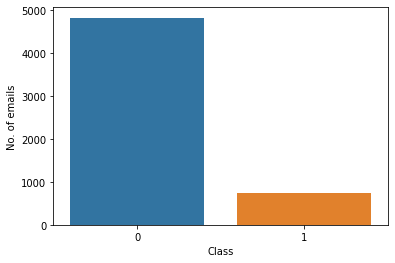

In [ ]:
import seaborn as sns

sns.countplot('spam', data = dataset)
plt.xlabel("Class")
plt.ylabel("No. of emails")
plt.show()

We can see that the dataset is very imbalanced. So let's not just rely on accuracy but calculate the precision and recall as well.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1score = f1_score(y_test, y_pred)

print('Precision = {:.4f}' .format(precision))
print('Recall = {:.4f}' .format(recall))
print('F1 Score = {:.4f}' .format(f1score))

Precision = 0.8767
Recall = 0.8591
F1 Score = 0.8678


As we can see our spam classifier is performing pretty well. The classifier has a precision of 0.87 meaning that 87% of the samples classified as spam by our classifier are actually spam. Also the classifier has a recall of 0.859 which means that 85.9% of the messages which are actually spam are classified as spam by our classifier. The f1 score too is good at 0.8678.




 ## Key Takeaways

* Applying a machine learning model is the final step of text classification..

* Naive Bayes classifier uses the Bayes Theorem to find the posterior probability of a document belonging to a class given the words present in the document.

* Naive Bayes predicts the class that has the maximum posterior probability.

* Naive Bayes is naive due to the assumption of independence among features which is almost never true.

